In [ ]:
%pip install matplotlib

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('GoldRate - History_Data.csv')

# --- Data Cleaning and Initial Preprocessing ---
df['22K Rate'] = df['22K Rate'].str.replace(',', '', regex=True).astype(float)
df['24K Rate'] = df['24K Rate'].str.replace(',', '', regex=True).astype(float)

# Convert 'Date' column to datetime and set as index
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df.set_index('Date', inplace=True)
df.drop(columns=['Month', 'Year'], inplace=True)

# filling missing dates
full_date_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
full_df = pd.DataFrame(index=full_date_range)
df = full_df.merge(df, how='left', left_index=True, right_index=True)

# Filling missing values with the previous valid observation
df.ffill(inplace=True)

# Calculate the daily percentage change as the new target variable
df['Daily_Change'] = df['24K Rate'].pct_change() * 100

# Drop the first row which will have a NaN value for daily change
df.dropna(inplace=True)

# Create new time-based features
df['dayofweek'] = df.index.dayofweek
df['dayofyear'] = df.index.dayofyear
df['month'] = df.index.month
df['year'] = df.index.year

# Create lagged features for the 'Daily_Change'
for i in range(1, 8):
    df[f'lag_change_{i}'] = df['Daily_Change'].shift(i)

# Create rolling average features for the 'Daily_Change'
df['rolling_mean_change_7'] = df['Daily_Change'].rolling(window=7).mean()
df['rolling_std_change_7'] = df['Daily_Change'].rolling(window=7).std()

# Drop rows with NaN values created by lagged and rolling features
df.dropna(inplace=True)

In [ ]:
# Define features (X) and target (y)
X = df.drop(columns=['Daily_Change', '24K Rate', '22K Rate'])
y = df['Daily_Change']

# Split the data into training and testing sets (80% train, 20% test)
# Shuffle is set to False to maintain the time series order
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Initialize and train the Random Forest Regressor model
model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

# Evaluate the model's performance on predicting the daily change
r2 = r2_score(y_test, y_pred)
print(f"R-squared score on daily change: {r2:.4f}")

# Get the actual previous day's price to calculate the next day's predicted price
original_df = pd.read_csv('GoldRate - History_Data.csv')
original_df['Date'] = pd.to_datetime(original_df['Date'], format='%d/%m/%Y')
original_df['24K Rate'] = original_df['24K Rate'].str.replace(',', '', regex=True).astype(float)
original_df.set_index('Date', inplace=True)
previous_day_price = original_df['24K Rate'].iloc[len(original_df) - len(y_test) - 1]

# Get the actual last available gold rate from the test set
actual_last_day_price = df.loc[y_test.index[-1], '24K Rate']

# Get the previous day's gold rate from the test set
previous_day_price = df.loc[y_test.index[-2], '24K Rate']

# Calculate predicted next day's price
predicted_next_day_price = previous_day_price * (1 + (y_pred[-1] / 100))

# Forecast next day
last_row = df.iloc[-1:].drop(columns=['Daily_Change', '24K Rate', '22K Rate'])
next_day_change = model.predict(last_row)[0]
last_known_price = df['24K Rate'].iloc[-1]
forecast_price = last_known_price * (1 + next_day_change / 100)
forecast_date = df.index[-1] + pd.Timedelta(days=1)

R-squared score on daily change: 0.4560


In [165]:
import requests
from datetime import datetime

url = "https://api.gold-api.com/price/XAU"
response = requests.get(url)

forex_url = "https://open.er-api.com/v6/latest/USD"
fx_response = requests.get(forex_url).json()
usd_to_inr = fx_response["rates"]["INR"]

if response.status_code == 200:
    data = response.json()
    usd_price = data["price"]
    updated_time = datetime.fromisoformat(data["updatedAt"].replace("Z", "+00:00"))
else:
    print("Failed to fetch data:", response.status_code)


In [166]:
usd_to_inr = 84.0
inr_price = usd_price * usd_to_inr
inr_price_gram = inr_price / 28.3495

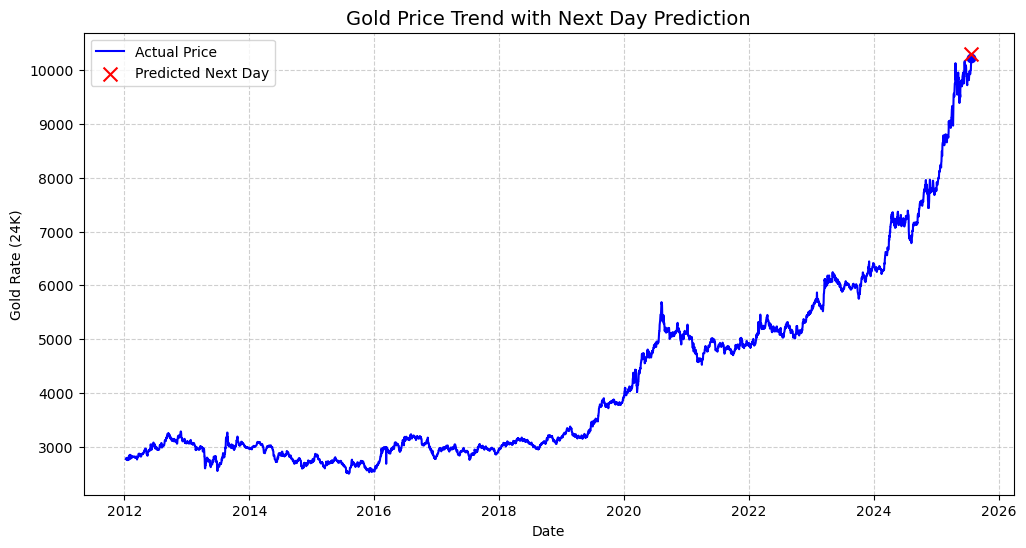

Predicted Gold Rate for the next day: 10206.38
Date: 2025-09-07 13:25:10 UTC
Gold Price (INR/oz): 301333.20
Gold Price (INR/gram): 10629.22


In [167]:
# Plot
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['24K Rate'], label="Actual Price", color='blue')

plt.scatter(df.index[-1], last_known_price, color='blue', marker='o')

plt.scatter(forecast_date, forecast_price, color='red', marker='x', s=100, label="Predicted Next Day")

plt.title("Gold Price Trend with Next Day Prediction", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Gold Rate (24K)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#predicted
print(f"Predicted Gold Rate for the next day: {predicted_next_day_price:.2f}")

#actual
print(f"Date: {updated_time.strftime('%Y-%m-%d %H:%M:%S')} UTC")
print(f"Gold Price (INR/oz): {inr_price:.2f}")
print(f"Gold Price (INR/gram): {inr_price / 28.3495:.2f}")
